# Fase 1 - EDA y Limpieza: Predicción de la Calidad del Vino Tinto

**1. Contexto del Dataset (El Problema de Negocio)**
Para mi proyecto de la Evaluación 2, elegí trabajar con el dataset "Red Wine Quality". Este archivo contiene 1.599 muestras de vino tinto de la variante "Vinho Verde", del norte de Portugal. Mi meta es predecir la **calidad del vino** (una nota del 0 al 10 dada por expertos) basándome únicamente en sus propiedades químicas (como el nivel de alcohol, el pH o el azúcar), sin necesidad de catarlo.

**2. Pasos que realizaré en este cuaderno:**
Para dejar mis datos listos para los futuros modelos de Machine Learning, en este archivo aplicaré el siguiente flujo de trabajo:

1. **Cargar el dataset:** Traeré los datos directamente desde mi repositorio clonado de GitHub y los leeré con Pandas.
2. **Diagnóstico Inicial:** Revisaré la estructura de la tabla (filas y columnas) y buscaré si existen valores nulos (espacios vacíos) que deba rellenar.
3. **Limpieza de Duplicados:** Buscaré y eliminaré las filas que estén exactamente repetidas para evitar que mi futuro modelo se sesgue o confunda.
4. **Análisis de Outliers (Valores Atípicos):** Usaré gráficos de caja (Boxplots) y el método matemático IQR para detectar números extremos. Evaluaré variables como el azúcar residual y el dióxido de azufre para decidir, basada en la química del vino, si los borro o los conservo.
5. **Análisis Visual y Correlación:** Graficaré cómo se distribuye mi variable objetivo (`quality`) y crearé un Mapa de Calor (Heatmap) para descubrir qué variables químicas tienen mayor impacto en la calidad del vino.
6. **Exportación y Sincronización:** Guardaré mi tabla final en la carpeta `/data/processed/` como un nuevo archivo `.csv` limpio, y subiré los cambios a GitHub para asegurar el versionado.

In [15]:
!git clone https://github.com/dongyah/EA2_SCY1101_Calidad_Vino.git
%cd EA2_SCY1101_Calidad_Vino

Cloning into 'EA2_SCY1101_Calidad_Vino'...
remote: Enumerating objects: 86, done.
remote: Counting objects: 100% (86/86), done.
remote: Compressing objects: 100% (75/75), done.
remote: Total 86 (delta 23), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (86/86), 630.37 KiB | 3.43 MiB/s, done.
Resolving deltas: 100% (23/23), done.
/content/EA2_SCY1101_Calidad_Vino/EA2_SCY1101_Calidad_Vino


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data/raw/winequality-red.csv')
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


## 1. Diagnóstico Inicial del Dataset

Procedemos a evaluar la estructura interna de los datos, identificando los tipos de variables asignadas automáticamente por Pandas y verificando de forma estricta la presencia de valores faltantes (nulos).

In [17]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


Como veo en el resultado, no hay nulos en el dataset, así que no tengo que rellenar ni imputar nada.

## 2. Limpieza de Datos: Tratamiento de Duplicados

Un paso crítico en la ingeniería de datos es mitigar el sobreajuste (*overfitting*) eliminando registros idénticos que no aporten variabilidad estadística real al modelo predictivo.

In [18]:
print("Duplicados:", df.duplicated().sum())
df = df.drop_duplicates()
df.shape

Duplicados: 240


(1359, 12)

Decidí borrar las filas duplicadas para que mi futuro modelo no se confunda, no se sesgue y no se sobreajuste con información repetida.

In [19]:
print(df.describe())

       fixed acidity  volatile acidity  citric acid  residual sugar  \
count    1359.000000       1359.000000  1359.000000     1359.000000   
mean        8.310596          0.529478     0.272333        2.523400   
std         1.736990          0.183031     0.195537        1.352314   
min         4.600000          0.120000     0.000000        0.900000   
25%         7.100000          0.390000     0.090000        1.900000   
50%         7.900000          0.520000     0.260000        2.200000   
75%         9.200000          0.640000     0.430000        2.600000   
max        15.900000          1.580000     1.000000       15.500000   

         chlorides  free sulfur dioxide  total sulfur dioxide      density  \
count  1359.000000          1359.000000           1359.000000  1359.000000   
mean      0.088124            15.893304             46.825975     0.996709   
std       0.049377            10.447270             33.408946     0.001869   
min       0.012000             1.000000         

Al principio analicé visualmente todas las variables y noté que varias presentaban valores atípicos (como los cloruros o el dióxido de azufre libre). Sin embargo, al investigar un poco más sobre el contexto de la producción y clasificación de vinos, me di cuenta de que esto puede pasar perfectamente en la vida real. Son variaciones químicas naturales, ya que existen vinos que son naturalmente más dulces o lotes que requieren más conservantes antimicrobianos.



## 3. Análisis Avanzado de Outliers (Valores Atípicos)

Para auditar la calidad de los datos, implementamos una función vectorizada basada en el Rango Intercuartílico (IQR) con el fin de cuantificar la presencia de valores extremos en todo el dataset de manera simultánea.

In [20]:
def mapear_outliers_iqr(dataframe):
    """Calcula límites basados en IQR y retorna un resumen del porcentaje de outliers por variable."""
    df_num = dataframe.select_dtypes(include=[np.number]).drop(
        columns=["quality"], errors="ignore"
    )
    Q1 = df_num.quantile(0.25)
    Q3 = df_num.quantile(0.75)
    IQR = Q3 - Q1

    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR

    # Detección lógica vectorizada
    mask_outliers = (df_num < lim_inf) | (df_num > lim_sup)

    resumen = mask_outliers.sum().reset_index()
    resumen.columns = ["Variable", "Total_Outliers"]
    resumen["Porcentaje"] = (
        (resumen["Total_Outliers"] / len(dataframe)) * 100
    ).round(2)

    return resumen.sort_values(by="Total_Outliers", ascending=False)


# Ejecución de la auditoría de outliers
mapear_outliers_iqr(df)

,Variable,Total_Outliers,Porcentaje
3,residual sugar,126,9.27
4,chlorides,87,6.40
9,sulphates,55,4.05
6,total sulfur dioxide,45,3.31
0,fixed acidity,41,3.02
7,density,35,2.58
8,pH,28,2.06
5,free sulfur dioxide,26,1.91
1,volatile acidity,19,1.40
10,alcohol,12,0.88


### Decisión Científica sobre los Outliers:

Al revisar los límites matemáticos del IQR, me di cuenta de que las variables que tienen la mayor cantidad de valores atípicos son el Azúcar Residual (residual_sugar con 126 outliers) y los Cloruros (chlorides con 87 outliers). Además, noté algo rarísimo en el Dióxido de Azufre Total (total_sulfur_dioxide con 45 outliers), ya que aunque son menos casos, su valor máximo se dispara bruscamente hasta 289.00.

A pesar de que son muchísimos puntos fuera de las cajas o números altísimos, tomé la decisión de conservar todos estos datos en el dataset.
¿Por qué decidí conservarlos? Investigando sobre cómo se hace el vino, descubrí esto:

**Azúcar Residual (residual_sugar):** En el mundo del vino, que una botella sea inusualmente dulce no es un error de tipeo. A veces los productores interrumpen la fermentación a propósito o usan uvas súper maduras para lograr sabores distintos (como los vinos de cosecha tardía).

**Cloruros (chlorides):** Esta es la sal del vino. Que un vino sea más salado depende directamente del tipo de tierra donde se plantó la uva y del agua con la que se regó. Como estos vinos "Vinho Verde" son del norte de Portugal, es súper normal y natural que algunas parcelas tengan más minerales o influencia costera.

**Dióxido de Azufre Total (total_sulfur_dioxide):** Estos son básicamente los conservantes químicos. Que un vino tenga un nivel tan alto como 289.00 no es que alguien haya tecleado mal en el sistema, sino que algunos lotes legítimamente requieren una mayor adición de este compuesto para evitar que el vino se oxide o le crezcan microbios.

Si hubiera borrado estas filas a ciegas basándome solamente en que la matemática decía que eran "anormales", le habría quitado información súper valiosa a mi modelo. Destruiría la representatividad de los vinos reales, por lo que preferí dejarlos y que la Inteligencia Artificial aprenda a reconocer estos casos legítimos de la producción vitivinícola.

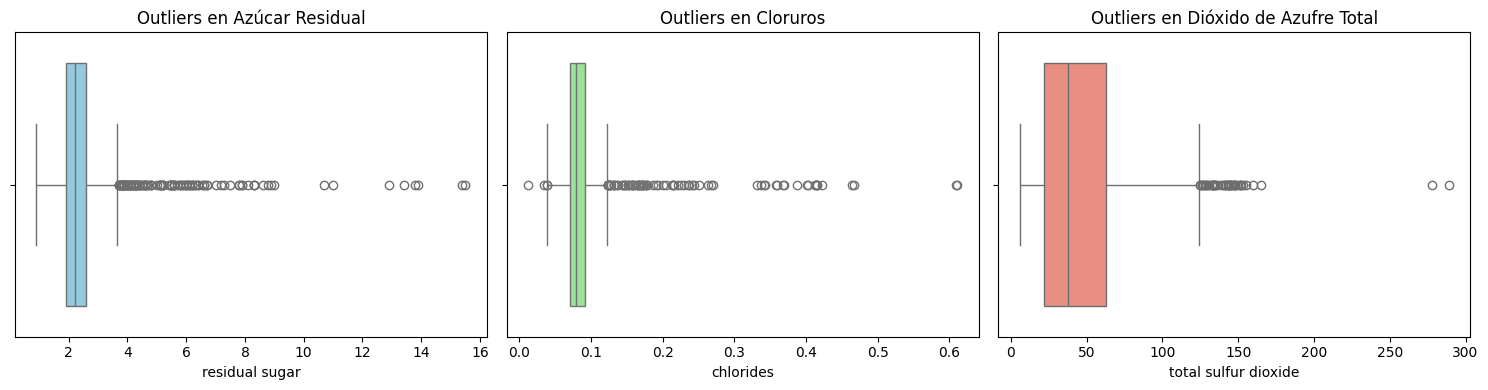

In [27]:
# Hago los boxplots de las 3 columnas que más me llamaron la atención por sus outliers
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 4))

# Gráfico 1: El que tiene más cantidad de outliers
plt.subplot(1, 3, 1)
sns.boxplot(x=df['residual sugar'], color='skyblue')
plt.title('Outliers en Azúcar Residual')

# Gráfico 2: El segundo con más cantidad
plt.subplot(1, 3, 2)
sns.boxplot(x=df['chlorides'], color='lightgreen')
plt.title('Outliers en Cloruros')

# Gráfico 3: El que tiene el valor más extremo (289.0)
plt.subplot(1, 3, 3)
sns.boxplot(x=df['total sulfur dioxide'], color='salmon')
plt.title('Outliers en Dióxido de Azufre Total')

plt.tight_layout()
plt.show()

## 4. Análisis Exploratorio de Datos Visual (EDA)

Estudiaremos el comportamiento y distribución de nuestra variable objetivo (`quality`) y las correlaciones lineales existentes entre los descriptores químicos a través de gráficos optimizados para la toma de decisiones.

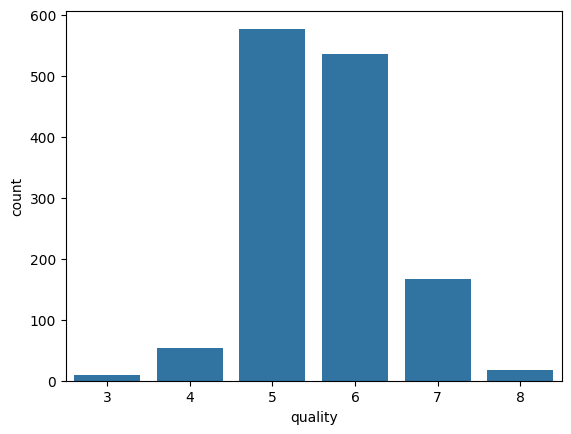

In [21]:
sns.countplot(x=df['quality'])
plt.show()

La mayoría de los vinos tienen una calidad de 5 o 6. Hay muy pocos en los extremos, lo que significa que las clases de mi variable objetivo están desbalanceadas.

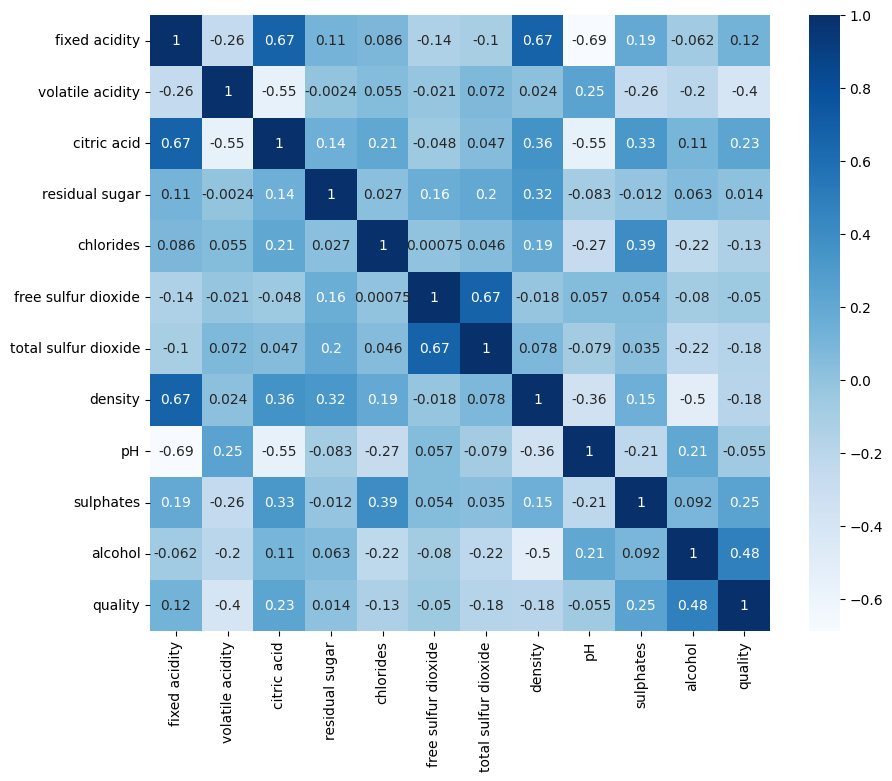

In [22]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="Blues")
plt.show()

En el heatmap puedo observar que el nivel de `alcohol` es la variable que tiene la mejor correlación positiva con la calidad del vino.

## 5. Exportación del Dataset Limpio

Concluido el proceso de diagnóstico, remoción de duplicados y análisis exploratorio, almacenamos el producto final en la carpeta correspondiente para la siguiente fase

In [23]:
import os
os.makedirs('data/processed', exist_ok=True)
df.to_csv('data/processed/winequality_clean.csv', index=False)
print("Datos guardados localmente")

Datos guardados localmente


In [24]:
import os

# Configure Git user identity
!git config --global user.email "bel.toloza@duocuc.cl"
!git config --global user.name "dongyah"

In [25]:
# Subir a github
!git add .
!git commit -m "Fase 1: EDA y dataset limpio guardado"
!git push origin main

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean
fatal: could not read Username for 'https://github.com': No such device or address


In [26]:
from google.colab import files

files.download('data/processed/winequality_clean.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>